In [3]:
import pandas as pd

df = pd.read_csv("1980sClassics.csv")

print(df.head())
print(df.columns)
print(df.shape)

                   Track              Artist Duration  Time_Signature  \
0                   Babe                Styx     3:38               4   
1               The Rose        Bette Midler     4:04               4   
2                   Cars          Gary Numan     4:08               4   
3                  Magic  Olivia Newton-John     2:17               4   
4  We Don’t Talk Anymore       Cliff Richard     3:37               4   

   Danceability  Energy  Key  Loudness  Mode  Speechiness  Acousticness  \
0         0.700   0.582   11    -5.960     0       0.0356       0.05020   
1         0.264   0.640    8    -6.221     1       0.0442       0.03930   
2         0.338   0.562    9    -7.181     1       0.0290       0.03900   
3         0.911   0.689    1    -6.176     1       0.2650       0.00119   
4         0.728   0.563    1    -8.053     0       0.1340       0.62100   

   Instrumentalness  Liveness  Valence    Tempo  Popularity  Year  
0          0.000000    0.0881    0.785  11

In [4]:
features = [
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence",
    "Tempo"
]

X = df[features]

print(X.head())

   Danceability  Energy  Loudness  Speechiness  Acousticness  \
0         0.700   0.582    -5.960       0.0356       0.05020   
1         0.264   0.640    -6.221       0.0442       0.03930   
2         0.338   0.562    -7.181       0.0290       0.03900   
3         0.911   0.689    -6.176       0.2650       0.00119   
4         0.728   0.563    -8.053       0.1340       0.62100   

   Instrumentalness  Liveness  Valence    Tempo  
0          0.000000    0.0881    0.785  116.712  
1          0.000002    0.1510    0.190   84.828  
2          0.000000    0.1070    0.259  149.907  
3          0.000000    0.0704    0.546  140.034  
4          0.000000    0.1790    0.352  100.017  


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 4.85541205e-01 -2.52165164e-01  7.64404732e-01 -3.95432660e-01
  -7.82370226e-01 -2.71079076e-01 -5.56802145e-01  7.05740011e-01
  -1.59751698e-01]
 [-2.39345930e+00  3.25884593e-02  6.96222493e-01 -2.41067468e-01
  -8.26231708e-01 -2.71064360e-01 -1.69884241e-01 -1.60274136e+00
  -1.37475917e+00]
 [-1.90482160e+00 -3.50356069e-01  4.45437245e-01 -5.13898971e-01
  -8.27438904e-01 -2.71079076e-01 -4.40542235e-01 -1.33503512e+00
   1.10521421e+00]
 [ 1.87881897e+00  2.73156176e-01  7.07978052e-01  3.72216911e+00
  -9.79585932e-01 -2.71079076e-01 -6.65680475e-01 -2.21532340e-01
   7.28982594e-01]
 [ 6.70431146e-01 -3.45446524e-01  2.17640646e-01  1.37079234e+00
   1.51452275e+00 -2.71079076e-01  2.35266342e-03 -9.74213662e-01
  -7.95950095e-01]]


In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

print(inertias)

[7244.147072987121, 6520.27251920513, 5758.44175744493, 5274.798260673208, 5033.075219709049, 4376.326989593431, 4308.315378376189, 3884.024656183014, 3723.4218923017866]


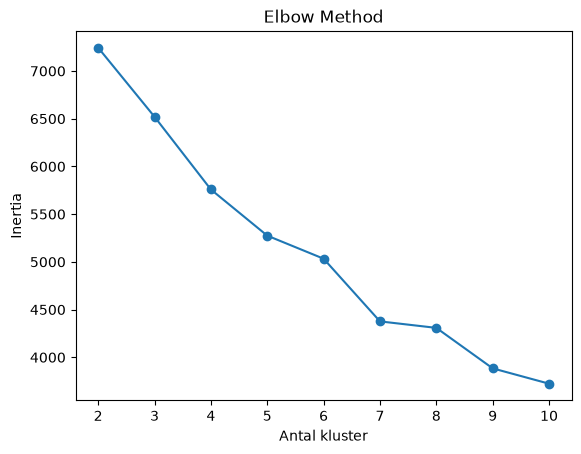

In [7]:
plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Antal kluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [8]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[0.23472979188256562, 0.2265850253069147, 0.19252946669469642, 0.18789921587496072, 0.15239685763012842, 0.1700939147028405, 0.15624664328080745, 0.17567781225359264, 0.16739464067741408]


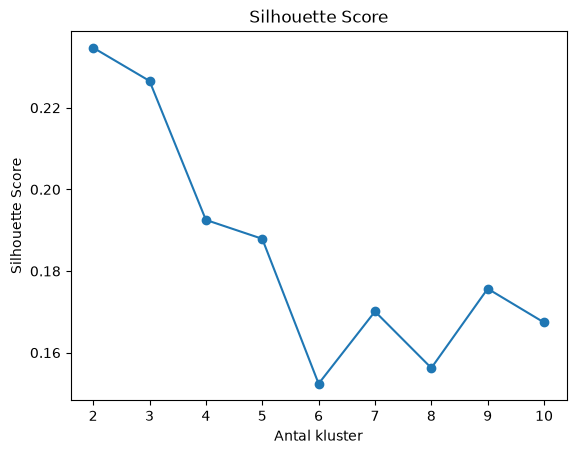

In [9]:
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Antal kluster")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print(df[["Track", "Artist", "Cluster"]].head(20))

                             Track                    Artist  Cluster
0                             Babe                      Styx        0
1                         The Rose              Bette Midler        3
2                             Cars                Gary Numan        3
3                            Magic        Olivia Newton-John        4
4            We Don’t Talk Anymore             Cliff Richard        1
5                           Desire                 Andy Gibb        3
6                        Real Love           Doobie Brothers        3
7                    Rock With You           Michael Jackson        0
8                             Sara             Fleetwood Mac        3
9                      Upside Down                Diana Ross        0
10   Escape (THE Piña Colada Song)             Rupert Holmes        0
11                             Him             Rupert Holmes        3
12                            Lady              Kenny Rogers        1
13  It’s Still Rock 

In [11]:
print(df["Cluster"].value_counts().sort_index())

Cluster
0    439
1    232
2     32
3    219
4     76
Name: count, dtype: int64


In [12]:
cluster_means = df.groupby("Cluster")[features].mean()

print(cluster_means.round(3))

         Danceability  Energy  Loudness  Speechiness  Acousticness  \
Cluster                                                              
0               0.731   0.690    -8.724        0.050         0.153   
1               0.534   0.398   -11.603        0.039         0.519   
2               0.609   0.462   -13.220        0.057         0.503   
3               0.515   0.755    -6.574        0.052         0.132   
4               0.631   0.749    -6.369        0.173         0.154   

         Instrumentalness  Liveness  Valence    Tempo  
Cluster                                                
0                   0.020     0.137    0.784  114.104  
1                   0.015     0.164    0.356  112.437  
2                   0.809     0.131    0.399  130.952  
3                   0.012     0.178    0.529  141.825  
4                   0.021     0.486    0.609  121.520  


In [13]:
for cluster in sorted(df["Cluster"].unique()):
    print(f"\n--- Cluster {cluster} ---")
    print(df[df["Cluster"] == cluster][["Track", "Artist"]].head(10))


--- Cluster 0 ---
                             Track                    Artist
0                             Babe                      Styx
7                    Rock With You           Michael Jackson
9                      Upside Down                Diana Ross
10   Escape (THE Piña Colada Song)             Rupert Holmes
13  It’s Still Rock And Roll To Me                Billy Joel
14                    On The Radio              Donna Summer
15                           Still                Commodores
16      Another One Bites The Dust                     Queen
17                          Longer             Dan Fogelberg
18                 Please Don’t Go  KC and the Sunshine Band

--- Cluster 1 ---
                          Track              Artist
4         We Don’t Talk Anymore       Cliff Richard
12                         Lady        Kenny Rogers
19              All Out Of Love          Air Supply
22            Daydream Believer         Anne Murray
24                     Dreaming

In [14]:
for cluster in sorted(df["Cluster"].unique()):
    print(f"\n--- Cluster {cluster} ---")
    print(
        df[df["Cluster"] == cluster][["Track", "Artist"]]
        .head(10)
        .to_string(index=False)
    )


--- Cluster 0 ---
                         Track                   Artist
                          Babe                     Styx
                 Rock With You          Michael Jackson
                   Upside Down               Diana Ross
 Escape (THE Piña Colada Song)            Rupert Holmes
It’s Still Rock And Roll To Me               Billy Joel
                  On The Radio             Donna Summer
                         Still               Commodores
    Another One Bites The Dust                    Queen
                        Longer            Dan Fogelberg
               Please Don’t Go KC and the Sunshine Band

--- Cluster 1 ---
                      Track             Artist
      We Don’t Talk Anymore      Cliff Richard
                       Lady       Kenny Rogers
            All Out Of Love         Air Supply
          Daydream Believer        Anne Murray
                   Dreaming      Cliff Richard
                  More Love         Kim Carnes
              Wom

In [15]:
for cluster in sorted(df["Cluster"].unique()):
    print(f"\n--- Cluster {cluster} ---")
    
    songs = df[df["Cluster"] == cluster][["Track", "Artist"]].head(5)
    
    print(songs.to_string(index=False))


--- Cluster 0 ---
                         Track          Artist
                          Babe            Styx
                 Rock With You Michael Jackson
                   Upside Down      Diana Ross
 Escape (THE Piña Colada Song)   Rupert Holmes
It’s Still Rock And Roll To Me      Billy Joel

--- Cluster 1 ---
                Track        Artist
We Don’t Talk Anymore Cliff Richard
                 Lady  Kenny Rogers
      All Out Of Love    Air Supply
    Daydream Believer   Anne Murray
             Dreaming Cliff Richard

--- Cluster 2 ---
                            Track                    Artist
                        Funkytown                 Lipps Inc
                Let’s Get Serious          Jermaine Jackson
Don’t Fall In Love With A Dreamer Kenny Rogers & Kim Carnes
  You’re The Only Woman (YOU & I)                  Ambrosia
                          Rapture                   Blondie

--- Cluster 3 ---
    Track          Artist
 The Rose    Bette Midler
     Cars     

In [16]:
for cluster in [3, 4]:
    print(f"\n--- Cluster {cluster} ---")
    
    songs = df[df["Cluster"] == cluster][["Track", "Artist"]].head(10)
    
    print(songs.to_string(index=False))


--- Cluster 3 ---
                    Track             Artist
                 The Rose       Bette Midler
                     Cars         Gary Numan
                   Desire          Andy Gibb
                Real Love    Doobie Brothers
                     Sara      Fleetwood Mac
                      Him      Rupert Holmes
       Biggest Part Of Me           Ambrosia
                     Jane Jefferson Starship
         You May Be Right         Billy Joel
Let My Love Open The Door     Pete Townshend

--- Cluster 4 ---
             Track                               Artist
             Magic                   Olivia Newton-John
          Cruisin’                      Smokey Robinson
         Fire Lake Bob Seger and the Silver Bullet Band
      Off The Wall                      Michael Jackson
      One Fine Day                          Carole King
All Over The World             Electric Light Orchestra
              Time             The Alan Parsons Project
            9 To 5 

Jag genomförde en K-means-klustring på datasetet med 998 låtar från 1980-talet. Jag använde Danceability, Energy, Loudness, Speechiness, Acousticness, Instrumentalness, Liveness, Valence och Tempo som features och standardiserade dessa innan klustringen.

Jag undersökte först olika antal kluster med inertia och elbow-metoden. Kurvan visade att förbättringen började avta ungefär vid 5–7 kluster. Jag undersökte även silhouette score, där 2 kluster hade högst värde. För att få en mer detaljerad analys valde jag därefter 5 kluster.

Klustren hade olika musikaliska egenskaper. Ett stort kluster bestod främst av dansanta och positiva låtar, ett annat av lugnare och mer akustiska låtar. Ett litet kluster utmärkte sig genom mycket hög instrumentalness. Ytterligare kluster bestod främst av energiska/snabba låtar respektive energiska låtar med högre liveness och speechiness.

Resultatet visar att K-means kan användas för att hitta grupper av musik med liknande ljudegenskaper utan att modellen får information om exempelvis genre